In [72]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


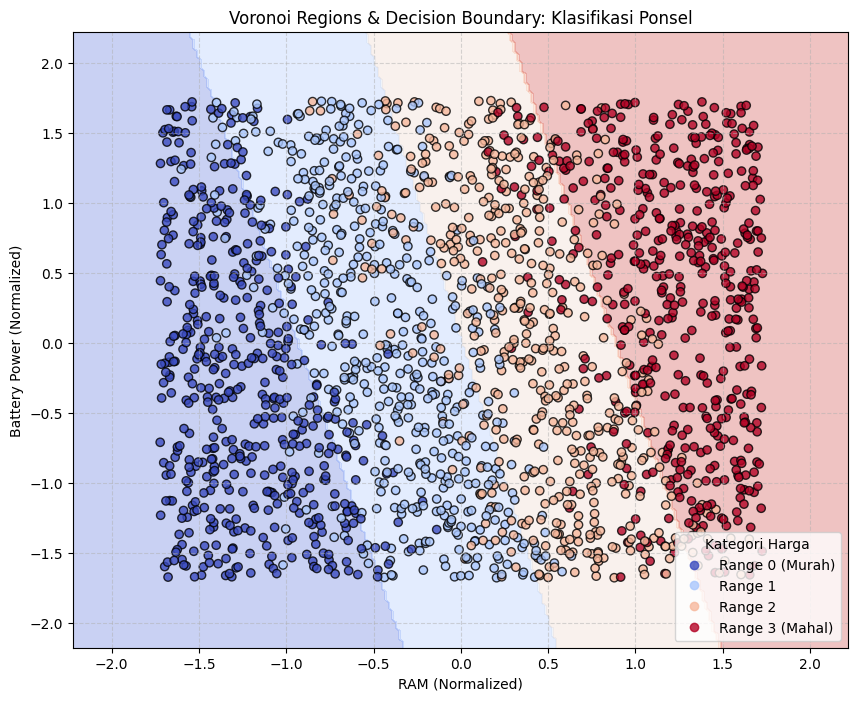

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PERSIAPAN DATA ---
# Sesuaikan path ini dengan lokasi file dataset di Google Drive-mu
# (Ingat: File dataset Kaggle ini biasanya bernama 'train.csv')
path_file = '/content/drive/MyDrive/train.csv'
df = pd.read_csv(path_file)

# Ambil fitur 'ram' dan 'battery_power' sesuai instruksi
X = df[['ram', 'battery_power']].values
y = df['price_range'].values # Target kelas: 0, 1, 2, 3

# Normalisasi Z-score (Wajib dilakukan agar fungsi eksponensial di Softmax tidak error/overflow)
mean_X = np.mean(X, axis=0)
std_X = np.std(X, axis=0)
X_norm = (X - mean_X) / std_X

# --- 2. FUNGSI MATEMATIKA DARI SCRATCH ---

# Fungsi Softmax
def softmax(z):
    # Dikurangi nilai max untuk stabilitas numerik
    exp_z = np.exp(z - np.max(z))
    return exp_z / np.sum(exp_z)

# Fungsi Cross-Entropy Loss
def cross_entropy_loss(y_true_one_hot, y_pred_prob):
    # Ditambahkan nilai epsilon kecil untuk mencegah log(0) yang bernilai infinity
    epsilon = 1e-15
    y_pred_prob = np.clip(y_pred_prob, epsilon, 1. - epsilon)
    return -np.sum(y_true_one_hot * np.log(y_pred_prob))

# --- 3. IMPLEMENTASI SGD ---
num_features = X_norm.shape[1] # Ada 2 fitur
num_classes = len(np.unique(y)) # Ada 4 kelas target (0 sampai 3)

# Inisialisasi Parameter
# Matrix W berukuran (4 kelas x 2 fitur) dan vector b berukuran (4 kelas)
W = np.zeros((num_classes, num_features))
b = np.zeros(num_classes)

eta = 0.05 # Learning rate
epochs = 50
n_samples = len(X_norm)

for epoch in range(epochs):
    # Stochastic: acak data tiap iterasi
    indices = np.random.permutation(n_samples)

    for i in indices:
        x_i = X_norm[i]
        y_i = y[i]

        # Forward pass: Hitung skor z dan probabilitas f(x)
        z_i = np.dot(W, x_i) + b
        f_x_i = softmax(z_i)

        # Konversi target menjadi One-Hot Vector
        y_one_hot = np.zeros(num_classes)
        y_one_hot[y_i] = 1.0

        # Hitung Error (epsilon): Selisih prediksi probabilitas dengan target one-hot
        epsilon_i = f_x_i - y_one_hot

        # Update Bobot (W) dan Bias (b)
        W = W - eta * np.outer(epsilon_i, x_i)
        b = b - eta * epsilon_i

# --- 4. VISUALISASI DECISION BOUNDARY (VORONOI REGIONS) ---
# Membuat grid koordinat untuk mengecat latar belakang (region)
x_min, x_max = X_norm[:, 0].min() - 0.5, X_norm[:, 0].max() + 0.5
y_min, y_max = X_norm[:, 1].min() - 0.5, X_norm[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Lakukan prediksi untuk setiap titik di dalam grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = []
for point in grid_points:
    z_scores = np.dot(W, point) + b
    probs = softmax(z_scores)
    Z.append(np.argmax(probs))
Z = np.array(Z).reshape(xx.shape)

# Proses plotting
plt.figure(figsize=(10, 8))

# Mewarnai Voronoi Regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Menaruh titik-titik data aktual di atas regions
scatter = plt.scatter(X_norm[:, 0], X_norm[:, 1], c=y, edgecolor='k', cmap=plt.cm.coolwarm, alpha=0.8)

plt.title('Voronoi Regions & Decision Boundary: Klasifikasi Ponsel')
plt.xlabel('RAM (Normalized)')
plt.ylabel('Battery Power (Normalized)')

# Keterangan Legenda
handles, labels = scatter.legend_elements()
plt.legend(handles, ['Range 0 (Murah)', 'Range 1', 'Range 2', 'Range 3 (Mahal)'], title="Kategori Harga")

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()